# Tensors:


## Basic tensors:

In [30]:
import torch

a = torch.rand(2, 3)
b = torch.rand(2, 3)
print(a)

print(a)

tensor([[0.970, 0.289, 0.759],
        [0.603, 0.866, 0.656]])
tensor([[0.970, 0.289, 0.759],
        [0.603, 0.866, 0.656]])


In [31]:
add = a + b
sub = a - b
mul = a * b

print(add)
print(sub)
print(mul)

tensor([[1.021, 1.000, 1.167],
        [1.586, 1.581, 0.775]])
tensor([[ 0.920, -0.422,  0.352],
        [-0.380,  0.152,  0.538]])
tensor([[0.049, 0.205, 0.310],
        [0.593, 0.619, 0.078]])


## Transpose:


In [32]:
a = torch.rand(2, 3)
c = b @ a.T
print(c)

tensor([[0.328, 0.064],
        [0.652, 0.516]])


## Broadcasting:

In [33]:
# simple
a = torch.tensor([[1], [2], [3]])
b = torch.tensor([4, 5, 6])
print(a + b)

# batch:
batch_size = 10
a = torch.rand(batch_size, 3, 4)
b = torch.rand(batch_size,4, 5)
c = torch.rand(4, 5)

a_mul_b = a @ b
print(a_mul_b.shape)
a_mul_c = a @ c
print(a_mul_c.shape)


tensor([[5, 6, 7],
        [6, 7, 8],
        [7, 8, 9]])
torch.Size([10, 3, 5])
torch.Size([10, 3, 5])


## Tensor Reshape:

In [34]:
import torch

a = torch.rand(size = (2, 3, 4))
print(a.shape)

a_flat = a.reshape(-1)
print(a_flat.shape)

torch.Size([2, 3, 4])
torch.Size([24])


In [35]:
a_transpose_1 = a.transpose(1, 0)
a_transpose_2 = a.transpose(1, 2)
print(a_transpose_1.shape)
print(a_transpose_2.shape)



torch.Size([3, 2, 4])
torch.Size([2, 4, 3])


In [36]:
a_perm = a.permute([1, 2, 0])
print(a_perm.shape)

torch.Size([3, 4, 2])


In [37]:
a_1 = a.reshape(6, -1)
a_2 = a.reshape(8, -1)
print(a_1.shape)
print(a_2.shape)

torch.Size([6, 4])
torch.Size([8, 3])


## Expanding(unsquezing) and Squeezing:

In [38]:
a_expanded = a.unsqueeze(1)
a_squeezed = a_expanded.squeeze(1)
print(a_expanded.shape)
print(a_squeezed.shape)


torch.Size([2, 1, 3, 4])
torch.Size([2, 3, 4])


## Basic autograd with scalar values

In [39]:
import torch

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = x**2 + y**3
print(z)


tensor(31., grad_fn=<AddBackward0>)


In [40]:
z.backward()
dz_dx = x.grad
dz_dy = y.grad
print(f"dz/dx = [green]{dz_dx}[/green]")
print(f"dz/dy = [green]{dz_dy}[/green]")

dz/dx = [green]4.0[/green]
dz/dy = [green]27.0[/green]


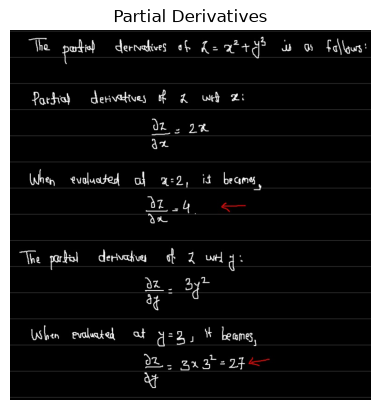

In [41]:
# Display a warning if the image 'partial_derivatives.png' is missing
import os
from PIL import Image
import matplotlib.pyplot as plt

img_path = 'images/partial_derivatives.jpeg'

if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Partial Derivatives')
    plt.show()
else:
    print(f"Warning: Image file '{img_path}' not found. Skipping image display.")

## Chain rule:  

In [42]:
import torch

x = torch.tensor(2.0, requires_grad = True)
y = x**2
z = y+1
w = z**2

dw_dz = torch.autograd.grad(outputs = w, inputs = z, retain_graph = True)[0]
dz_dy = torch.autograd.grad(outputs = z, inputs = y, retain_graph = True)[0]
dy_dx = torch.autograd.grad(outputs = y, inputs = x, retain_graph = True)[0]

print(f"dw_dz: {dw_dz}")
print(f"dz_dy: {dz_dy}")
print(f"dy_dx: {dy_dx}")

dw_dz: 10.0
dz_dy: 1.0
dy_dx: 4.0


In [43]:
dw_dx = dw_dz*dz_dy*dy_dx
print(dw_dx)

tensor(40.)


In [44]:
w.backward()
print(x.grad)

tensor(40.)


In [45]:
# backward propagation on vector:
import torch

x = torch.tensor([-1.0, 2.0, 1.0], requires_grad = True)
y = x**2
z = y+1
w = z**2

w.sum().backward()
print(x.grad)

tensor([-8., 40.,  8.])


## Gradient Accumulation:

In [46]:
x = torch.tensor(1.0, requires_grad = True)
y1 = x**2
y1.backward()
print(x.grad)
y2 = x**3
y2.backward()
print(x.grad)


tensor(2.)
tensor(5.)


In [47]:
x = torch.tensor(1.0, requires_grad = True)
y1 = x**2
y1.backward()
print(x.grad)

x.grad.zero_()
print(x.grad)


y2 = x**3
y2.backward()
print(x.grad)


tensor(2.)
tensor(0.)
tensor(3.)


## Vector Autograd:

In [48]:
import torch

x = torch.tensor([1.0, 2.0, 3.0], requires_grad = True)
y = torch.tensor([3.0, 5.0, 6.0], requires_grad = True)

z0 = x**2 + y**3
z = z0.sum()
print(z0)
print(z)


tensor([ 28., 129., 225.], grad_fn=<AddBackward0>)
tensor(382., grad_fn=<SumBackward0>)


In [49]:
z.backward()

dz_dx = x.grad
dz_dy = y.grad
print(x.grad)
print(y.grad)



tensor([2., 4., 6.])
tensor([ 27.,  75., 108.])


## Unexpected functios pytorch can flow gradients through:

In [50]:
import torch.nn.functional as F

a = torch.tensor([1.0, 3.4, -2.9], requires_grad = True)
b = torch.tensor([10.0, 2.4, 1.2], requires_grad = True)

ans = torch.max(a, b)
print(f"max, ans={ans}")
ans = torch.where(a+b<3.0, a, b)
print(f"where, ans={ans}")
ans = torch.clamp(a, 1.0, 2.0)
print(f"clamp, ans={ans}")
ans = torch.abs(a)
print(f"abs, ans={ans}")
# ans = F.relu(x)
ans = torch.relu(a)
print(f"relu, ans={ans}")


max, ans=tensor([10.000,  3.400,  1.200], grad_fn=<MaximumBackward0>)
where, ans=tensor([10.000,  2.400, -2.900], grad_fn=<WhereBackward0>)
clamp, ans=tensor([1., 2., 1.], grad_fn=<ClampBackward1>)
abs, ans=tensor([1.000, 3.400, 2.900], grad_fn=<AbsBackward0>)
relu, ans=tensor([1.000, 3.400, 0.000], grad_fn=<ReluBackward0>)


In [51]:
ans = torch.round(a)
print(f"round, ans={ans}")
ans = torch.sign(a)
print(f"sign, ans={ans}")

# Step function
input = torch.tensor(-1.0)
ans = torch.heaviside(input, a)
print(f"heaviside, ans={ans}")

input = torch.tensor(0.0)
ans = torch.heaviside(input, a)
print(f"heaviside, ans={ans}")

input = torch.tensor(1.0)
ans = torch.heaviside(input, a)
print(f"heaviside, ans={ans}")



round, ans=tensor([ 1.,  3., -3.], grad_fn=<RoundBackward0>)
sign, ans=tensor([ 1.,  1., -1.], grad_fn=<SignBackward0>)
heaviside, ans=tensor([0., 0., 0.], grad_fn=<NotImplemented>)
heaviside, ans=tensor([ 1.000,  3.400, -2.900], grad_fn=<NotImplemented>)
heaviside, ans=tensor([1., 1., 1.], grad_fn=<NotImplemented>)


In [52]:
ans = torch.topk(a, 2)
# print(ans)
for val in ans:
    print(val)

tensor([3.400, 1.000], grad_fn=<TopkBackward0>)
tensor([1, 0])


#### max function example:

In [53]:
import torch
a = torch.tensor([1.0, 3.4, -2.9], requires_grad = True)
b = torch.tensor([10.0, 2.4, 1.2], requires_grad = True)

z = torch.max(a, b)
loss = z.sum()
loss.backward()
print(x.grad)
print(y.grad)
print(loss)

tensor([2., 4., 6.])
tensor([ 27.,  75., 108.])
tensor(14.600, grad_fn=<SumBackward0>)


## Linear models and MLP:

In [54]:
import pandas as pd
from sklearn.preprocessing import normalize

In [55]:

df = pd.DataFrame({
    'area': [120, 180, 150, 210, 105],
    "age": [5, 2, 1, 2, 1],
    "price": [30, 90, 100, 180, 85]
})

print(df.to_string())

   area  age  price
0   120    5     30
1   180    2     90
2   150    1    100
3   210    2    180
4   105    1     85


In [56]:
df = normalize(df)
print(df)


[[0.96935087 0.04038962 0.24233772]
 [0.89438303 0.00993759 0.44719151]
 [0.83203749 0.00554692 0.55469166]
 [0.75923675 0.00723083 0.65077436]
 [0.77722358 0.00740213 0.62918099]]


In [57]:
X = torch.tensor(df[:, :2], dtype=torch.float32)
Y = torch.tensor(df[:, 2:], dtype=torch.float32)
print(X)
print(Y)


tensor([[0.969, 0.040],
        [0.894, 0.010],
        [0.832, 0.006],
        [0.759, 0.007],
        [0.777, 0.007]])
tensor([[0.242],
        [0.447],
        [0.555],
        [0.651],
        [0.629]])


In [58]:
W = torch.rand(size = (2, 1), requires_grad = True)
B = torch.rand(1, requires_grad = True)

# print(stringify_WB(W, B))



In [59]:
pred = X@W + B
error = (Y-pred)**2
loss = error.mean()
old_loss = loss
# print(get_error_df(Y, pred, error))
# print(loss.items())

In [60]:
loss.backward()

dW = W.grad
dB = B.grad
# print(stringify_grads(W, B, dW, dB))


In [61]:
lr = 0.2
with torch.no_grad():
    W = W - lr*dW
    B = B - lr*dB

print(W, B)

tensor([[0.178],
        [0.328]]) tensor([0.315])


In [62]:
pred = X@W + B
new_loss = ((Y - pred)**2).mean()
print("old_loss", old_loss)
print("new_loss", new_loss)



old_loss tensor(0.036, grad_fn=<MeanBackward0>)
new_loss tensor(0.029)


### FULL training (single layer):

In [63]:
from torch.optim import SGD

# Initialize the weights and bias
W = torch.rand(size=(2, 1), requires_grad = True)
B = torch.rand(1, requires_grad = True)

# initialize the optimizer
optimizer = SGD(params = (W, B), lr = 0.1)

for step in range(10):
    pred = X@W + B # Forward pass
    loss = ((Y - pred)**2).mean() # Calculate loss
    loss.backward() # Calculate the gradients
    optimizer.step() # Update W and B
    optimizer.zero_grad() # Reset all gradeints
    print(f"Step: {step}, Loss: {loss.item():.4f}")


Step: 0, Loss: 0.0404
Step: 1, Loss: 0.0331
Step: 2, Loss: 0.0300
Step: 3, Loss: 0.0286
Step: 4, Loss: 0.0280
Step: 5, Loss: 0.0277
Step: 6, Loss: 0.0276
Step: 7, Loss: 0.0275
Step: 8, Loss: 0.0274
Step: 9, Loss: 0.0274


In [64]:
final_new_loss = ((Y - pred)**2).mean()
print(final_new_loss)

tensor(0.027, grad_fn=<MeanBackward0>)


## MLP training:

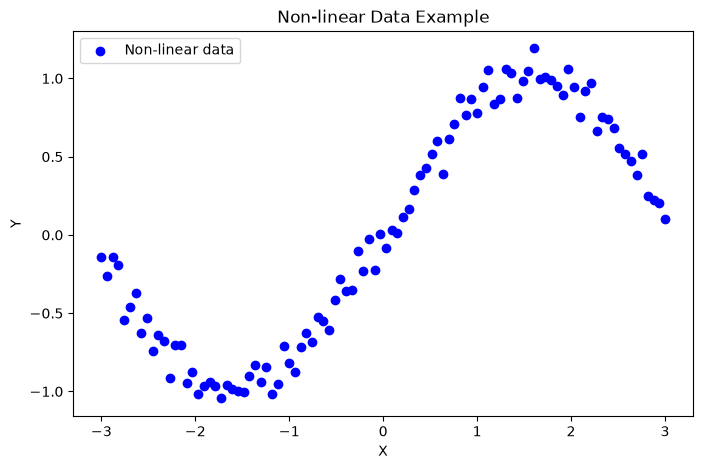

In [65]:
import torch
import matplotlib.pyplot as plt

# Generate some non-linear data
X = torch.unsqueeze(torch.linspace(-3, 3, 100), dim=1)
Y = torch.sin(X) + 0.1 * torch.randn(X.size())  # Example non-linear data

# Plot it
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), Y.numpy(), color='b', label='Non-linear data')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Non-linear Data Example')
plt.legend()
plt.show()

In [66]:
from torch import nn
from torch.nn import Sequential, MSELoss

hidden_dim = 128
model = Sequential(
    nn.Linear(in_features = 1, out_features = hidden_dim),
    nn.ReLU(),
    nn.Linear(in_features = hidden_dim, out_features = hidden_dim),
    nn.ReLU(),
    nn.Linear(in_features = hidden_dim, out_features = 1),
)
print(model)


Sequential(
  (0): Linear(in_features=1, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=1, bias=True)
)


In [67]:
# some non linear data
from torch.optim import SGD

optimizer = SGD(model.parameters(), lr=0.1)
loss_criterion = nn.MSELoss()

model.train()
for i in range(200):
    pred = model(X)
    
    loss = loss_criterion(pred, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%20==0:
        print(f"Step = {i}, loss = {loss.item():.3f}")


Step = 0, loss = 0.636
Step = 20, loss = 0.070
Step = 40, loss = 0.228
Step = 60, loss = 0.122
Step = 80, loss = 0.075
Step = 100, loss = 0.069
Step = 120, loss = 0.065
Step = 140, loss = 0.062
Step = 160, loss = 0.059
Step = 180, loss = 0.057


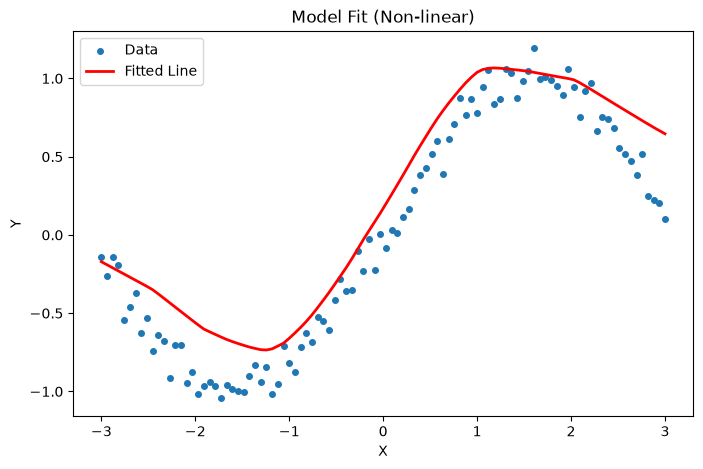

In [68]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    pred_Y = model(X)

plt.figure(figsize=(8,5))
plt.scatter(X.numpy(), Y.numpy(), label='Data', s=16)
plt.plot(X.numpy(), pred_Y.numpy(), c='r', label='Fitted Line', linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Model Fit (Non-linear)')
plt.legend()
plt.show()

## Complex NN: CNN

In [69]:
import torch
import torch.nn as nn
torch.set_printoptions(precision = 3)
cnn_layer = nn.Conv2d(
    in_channels = 3, out_channels = 16,
    kernel_size = 3, padding = 1, stride = 4
)
linear_layer = nn.Linear(4096, 10)
print(f"CNN block: {cnn_layer}, Linear: {linear_layer}")



CNN block: Conv2d(3, 16, kernel_size=(3, 3), stride=(4, 4), padding=(1, 1)), Linear: Linear(in_features=4096, out_features=10, bias=True)


In [70]:
random_image  = torch.rand(2, 3, 64, 64)
features = cnn_layer(random_image)
flattened = features.view(2, -1)
print(features.shape)
print(flattened.shape)

torch.Size([2, 16, 16, 16])
torch.Size([2, 4096])


In [71]:
logits = linear_layer(flattened)
probs = nn.Softmax(dim=-1)(logits)
print(logits.detach())
print(probs.detach())

tensor([[-0.197, -0.065, -0.281, -0.179,  0.123,  0.014, -0.532, -0.282,  0.120,
         -0.051],
        [-0.077,  0.084, -0.414, -0.153, -0.097,  0.141, -0.356, -0.241,  0.259,
         -0.008]])
tensor([[0.092, 0.105, 0.085, 0.094, 0.127, 0.114, 0.066, 0.085, 0.126, 0.107],
        [0.099, 0.116, 0.071, 0.092, 0.097, 0.123, 0.075, 0.084, 0.138, 0.106]])


## 

## LeNet:

In [72]:
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes = 10):
        super(LeNet5, self).__init__()

        # Features extraction layers
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)

        # classifier layers
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        # Conv layer 1
        x = F.ReLU(self.conv1(x))
        x = F.max_pool2d(x)

        # Conv layer 2
        x = F.ReLU(self.conv2(x))
        x = F.max_pool2d(x)
        
        # Conv layer 3
        x = F.ReLU(self.conv3(x))

        # Flatten and Fully connected
        x = F.ReLU(self.fc1(x))
        x = self.fc2(x)

        return x

print(LeNet5())
        


LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


## Deep Resnet:

In [73]:


class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResNetBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size = 3, 
            stride = stride, 
            padding = 1,
            bias = False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size = 3, 
            stride = 1, 
            padding = 1,
            bias = False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample  = downsample
    
    def forward(self):
        residual = x

        out = F.ReLU(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            residual = self.downsample(x)
        
        out += residual
        out = F.ReLU(out)

        return out


print(ResNetBlock(in_channels = 32, out_channels = 32))


ResNetBlock(
  (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)


In [74]:
class DeepResNet(nn.Module):
    def __init__(self, num_blocks):
        super(DeepResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias = False)
        self.bn1 = nn.BatchNorm2d(16)

        self.blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.blocks.append(ResNetBlock(16, 16))
            
    def forward(self, x):
        out = F.ReLU(self.bn1(self.conv1(x)))
        for block in self.blocks:
            out = block(out)
        return out

model = DeepResNet(36)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(total_params)


DeepResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (blocks): ModuleList(
    (0-35): 36 x ResNetBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
)
168656


## Encoder Decoder:

In [76]:
import torch
import torch.nn as nn

# The issue is that after encoding operations, you're left with a feature map that's too small for the 2x2 kernel in the decoder (Conv2d(4, 8, 2, stride=2)), resulting in the kernel being larger than the input, which is not allowed.

class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),    # (B,16,28,28)
            nn.ReLU(),
            nn.MaxPool2d(4, 4),                # (B,16,7,7)
            nn.Conv2d(16, 8, 3, padding=1),    # (B,8,7,7)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                # (B,8,3,3)
            nn.Conv2d(8, 4, 3, padding=1),     # (B,4,3,3)
            nn.ReLU()
        )

        # Decoder FIX: Use ConvTranspose2d to upsample instead of Conv2d with stride > 1
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 8, 2, stride=2),   # (B,8,6,6)
            nn.ReLU(),
            nn.ConvTranspose2d(8, 16, 2, stride=2),  # (B,16,12,12)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1), # (B,1,26,26)
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

model = AutoEncoder()
print(model)
dummy_input = torch.randn(10, 1, 28, 28)
reconstructed_output, latent_representation = model(dummy_input)
print(dummy_input.shape)
print(latent_representation.shape)
print(reconstructed_output.shape)

AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 8, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)
torch.Size([10, 1, 28, 28])
torch.Size([10, 4, 3, 3])
torch.Size([10, 1, 24, 24])


## RNNs:

In [78]:
import torch 
import torch.nn as nn

input_size = 10
hidden_size = 20
num_layers = 2

gru = nn.GRU(input_size, hidden_size, num_layers)

random_input = torch.randn(2, 3, 10)

print(f"There are {random_input.shape[1]} sequences, containing {random_input.shape[0]} items, and each items is an embedding of length {hidden_dim}")

There are 3 sequences, containing 2 items, and each items is an embedding of length 128


In [81]:
initial_hidden = torch.randn(2,3, 20)

output, hidden = gru(random_input, initial_hidden)

print(output.shape)
print("Each item is now an embedding of length", output.shape[2])

torch.Size([2, 3, 20])
Each item is now an embedding of length 20


## Encoder Decoder

In [88]:
class Encoder(nn.Module):
    def __init__(self, input_dim=32, emb_dim=32, hid_dim=32, n_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(input_size, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, n_layers)

    def forward(self, src):
        embedded = self.embedding(src)
        _, hidden = self.rnn(embedded)
        return hidden

class Decoder(nn.Module):
    def __init__(self, output_dim = 32, emb_dim=32, hid_dim=32, n_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, n_layers)
        self.fc_out = nn.Linear(hid_dim, output_dim)

    def forward(self):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        output, _ = self.rnn(embedded, hidden)
        prediction = self.fc_out(output.squeeze(0))
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src len, batch size], trg = [trg len, batch size]
        batch_size = trg.shape[1]
        # batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size)

        # pass through encoder
        hidden = self.encoder(src)
        input = trg[0, :]

        # Pass throguh the decoder
        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[t] = output
            top1 = output.argmax(1)
            teacher_force = random.rand() < teacher_forcing_ratio
            input = trg[t] if teacher_force else top1

        return outputs

encoder = Encoder()
print(f"Encoder: {encoder}")
decoder = Decoder()
print(f"Decoder: {decoder}")
model = Seq2Seq(encoder, decoder)
print(model)



Encoder: Encoder(
  (embedding): Embedding(10, 32)
  (rnn): GRU(32, 32)
)
Decoder: Decoder(
  (embedding): Embedding(32, 32)
  (rnn): GRU(32, 32)
  (fc_out): Linear(in_features=32, out_features=32, bias=True)
)
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10, 32)
    (rnn): GRU(32, 32)
  )
  (decoder): Decoder(
    (embedding): Embedding(32, 32)
    (rnn): GRU(32, 32)
    (fc_out): Linear(in_features=32, out_features=32, bias=True)
  )
)


## Attention Mechanism:

In [102]:
class SimpleAttention(nn.Module):
    def __init__(self, input_dim, attention_dim=64):
        super(SimpleAttention, self).__init__()
        # Linear layers for attention computation
        self.query = nn.Linear(input_dim, attention_dim)
        self.key = nn.Linear(input_dim, attention_dim)
        self.value = nn.Linear(input_dim, attention_dim)
        self.scale = torch.sqrt(torch.FloatTensor([attention_dim]))

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        batch_size, seq_len, input_dim = x.size()
        # Compute Q, K, V
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        attention_weights = F.softmax(attention_scores, dim=-1)
        attended_output = torch.matmul(attention_weights, V)
        return attended_output, attention_weights

class AttentionNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, seq_len):
        super(AttentionNetwork, self).__init__()
        self.attention = SimpleAttention(input_dim, hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, hidden_dim)
        )
        self.classifier = nn.Linear(hidden_dim * seq_len, output_dim)

    def forward(self, x):
        # self attention
        attended, attention_weights = self.attention(x)
        # Add & Norm (residual connection)
        x = self.layer_norm(attended +  F.pad(x, (0, attended.size(-1) - x.size(-1))))
        ffn_out = self.ffn(x)
        x = self.layer_norm(ffn_out + x)
        x = x.view(x.size(0), -1)
        output = self.classifier(x)
        return output, attention_weights

# Create attention model
attention_model = AttentionNetwork(input_dim = 50, hidden_dim=64, output_dim = 5, seq_len = 128)
X_att = torch.randn(3, 10, 50)
y_att, attention_weights = attention_model(X_att)
print(y_att)
print(attention_weights)
    



RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x640 and 8192x5)

In [ ]:
class SimpleAttention(nn.Module):
    def __init__(self, input_dim, attention_dim=64):
        super(SimpleAttention, self).__init__()
        # Linear layers for attention computation
        self.query = nn.Linear(input_dim, attention_dim)
        self.key = nn.Linear(input_dim, attention_dim)
        self.value = nn.Linear(input_dim, attention_dim)
        self.scale = torch.sqrt(torch.FloatTensor([attention_dim]))

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        batch_size, seq_len, input_dim = x.size()
        # Compute Q, K, V
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        attention_weights = F.softmax(attention_scores, dim=-1)
        attended_output = torch.matmul(attention_weights, V)
        return attended_output, attention_weights

class AttentionNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, seq_len):
        super(AttentionNetwork, self).__init__()
        self.attention = SimpleAttention(input_dim, hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, hidden_dim)
        )
        # The classifier maps per-sequence representations (hidden_dim -> output_dim)
        self.classifier = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch_size, seq_len, input_dim)
        attended, attention_weights = self.attention(x) # (batch, seq, hidden_dim)
        # Add & Norm (residual connection, possibly pad if input_dim != hidden_dim)
        if attended.size(-1) != x.size(-1):
            # Pad `x` feature dim up to hidden_dim if needed for residual connection
            residual = F.pad(x, (0, attended.size(-1) - x.size(-1)))
        else:
            residual = x
        x = self.layer_norm(attended + residual)
        ffn_out = self.ffn(x)
        x = self.layer_norm(ffn_out + x)  # (batch, seq, hidden_dim)
        # Pool across seq_len dimension to get per-sequence summary (e.g., mean pooling)
        x_pooled = x.mean(dim=1)  # (batch_size, hidden_dim)
        output = self.classifier(x_pooled)  # (batch_size, output_dim)
        return output, attention_weights

# Create attention model
attention_model = AttentionNetwork(input_dim=50, hidden_dim=64, output_dim=5, seq_len=10)
X_att = torch.randn(3, 10, 50)
y_att, attention_weights = attention_model(X_att)
print(y_att)s
print(attention_weights)


tensor([[ 0.002, -0.364, -0.511,  0.337,  0.535],
        [ 0.040, -0.213, -0.359, -0.195,  0.505],
        [-0.098, -0.329, -0.441, -0.084, -0.116]], grad_fn=<AddmmBackward0>)
tensor([[[0.116, 0.077, 0.155, 0.140, 0.085, 0.090, 0.090, 0.111, 0.044, 0.092],
         [0.203, 0.081, 0.101, 0.160, 0.065, 0.072, 0.072, 0.080, 0.085, 0.080],
         [0.053, 0.112, 0.091, 0.084, 0.087, 0.141, 0.116, 0.069, 0.128, 0.117],
         [0.112, 0.091, 0.078, 0.075, 0.113, 0.091, 0.155, 0.130, 0.070, 0.086],
         [0.076, 0.072, 0.091, 0.099, 0.095, 0.165, 0.129, 0.089, 0.098, 0.085],
         [0.132, 0.101, 0.089, 0.076, 0.123, 0.094, 0.144, 0.081, 0.100, 0.062],
         [0.089, 0.150, 0.074, 0.083, 0.163, 0.099, 0.098, 0.081, 0.100, 0.064],
         [0.135, 0.095, 0.073, 0.120, 0.067, 0.070, 0.114, 0.109, 0.126, 0.090],
         [0.069, 0.144, 0.098, 0.158, 0.135, 0.057, 0.074, 0.115, 0.066, 0.084],
         [0.088, 0.090, 0.152, 0.068, 0.085, 0.092, 0.096, 0.104, 0.103, 0.122]],

        [[0